# Chapitre 2 : Automatisation du script et modélisation sur Power BI
## Importation des librairies et lecture du dataset

In [1]:
import pandas as pd
df = pd.read_csv("/Users/milhane/PyCharmMiscProject/Projet Cyber 1/logs_securite_bruts.csv")
df.head(10)

,Date_Heure,Utilisateur,Adresse_IP,Localisation,Action,Statut
0,2026-03-01 08:24:00,employe_019,192.168.1.192,"Lyon, France",CONNEXION,ECHEC
1,2026-03-01 08:27:00,employe_018,192.168.1.139,"Paris, France",Connexion,succes
2,2026-03-01 08:29:00,employe_014,192.168.1.25,"Lyon, France",Connexion,succes
3,2026-03-01 08:49:00,employe_002,192.168.1.56,"Lyon, France",Connexion,NaN
4,2026-03-01 08:58:00,employe_015,192.168.1.41,"Grenoble, France",CONNEXION,ECHEC
5,2026-03-01 09:00:00,employe_014,192.168.1.45,"Lyon, France",CONNEXION,ECHEC
6,2026-03-01 09:20:00,employe_014,192.168.1.156,"Grenoble, France",telechargement,Echec
7,2026-03-01 09:36:00,employe_002,192.168.1.235,"Paris, France",CONNEXION,Echec
8,2026-03-01 09:43:00,employe_003,192.168.1.117,"Lyon, France",Connexion,succes
9,2026-03-01 09:55:00,employe_005,192.168.1.9,"Grenoble, France",Connexion,Succes


### Data Cleaning et parsing des dates

In [43]:
df['Action'] = df['Action'].str.strip().str.lower()
df['Statut'] = df['Statut'].str.strip().str.lower()
df['Adresse_IP'] = df['Adresse_IP'].fillna('inconnu')
df['Statut'] = df['Statut'].fillna('inconnu')
df['Date_Heure'] = pd.to_datetime(df['Date_Heure'])

### Préselection des utilisateurs suspects

In [39]:
df_echecs = df[ (df['Statut'] == 'echec') & (df['Action'] == 'connexion') ]
liste_employee = df_echecs['Utilisateur'].value_counts()

In [40]:
liste_suspects = []

for utilisateur, nombre_echecs in liste_employee.items():
    if nombre_echecs >= 25:
        liste_suspects.append(utilisateur)

print(liste_suspects)

['employe_004', 'employe_018']


### Automatisation du script
Grâce au script ci-dessus, on a donc un pool de suspect potentiels qui ont dépassé le seuil (fixé à 25). Pour réaliser cette automatisation, nous allons reprendre la même structure globale construite lors du chapitre 1. A la différence qu'on va ajouter cette fois un système de scoring. Cela permet de mieux pondérer le risque et c'est plus agréable à lire sur un PowerBI.

Également en terme de structure, nous allons ajouter une boucle au début pour que le script s'applique à tous les suspects. De même, on va créer un dictionnaire du nom de "score finaux" qui va venir stocker chaque data (score, plus gros nombre de tentatives, nombre d'IP utilisées, la ville d'origine, nombre total de tentatives).


In [46]:
scores_finaux = {}
for suspect in liste_suspects:
    score_risque = 0
    df_suspect = df_echecs[df_echecs['Utilisateur'] == suspect]
    df_suspect = df_suspect.sort_values(by='Date_Heure', ascending=False)
    echecs_par_jour = df_suspect.groupby(df_suspect['Date_Heure'].dt.date).size()
    nb_jours_suspects = 0


    for jour, nombre_echecs in echecs_par_jour.items():
        if nombre_echecs >= 15:
            nb_jours_suspects = nb_jours_suspects + 1
    if nb_jours_suspects > 0:
        score_risque = score_risque + 40 + (nb_jours_suspects - 1) * 5


    connexions_reussies = df[(df['Utilisateur'] == suspect) & (df['Statut'] == 'Succès')]
    if len(connexions_reussies) > 0:
        score_risque = score_risque + 30


    df_suspect = df_suspect.sort_values(by='Date_Heure', ascending=True)
    df_suspect['Ecart_Temps'] = df_suspect['Date_Heure'].diff()
    df_alertes = df_suspect[ df_suspect['Ecart_Temps'] < pd.Timedelta(seconds=3) ]
    jours_problematiques = df_alertes.groupby(df_alertes['Date_Heure'].dt.date).size()
    if len(jours_problematiques) > 0:
        score_risque = score_risque + (15 * len(jours_problematiques))


    ip_problematiques = df_alertes[['Adresse_IP', 'Localisation']].value_counts()
    if len(ip_problematiques) > 0:
        score_risque = score_risque + (15 * len(ip_problematiques))
    scores_finaux[suspect] = score_risque


#Définition des sous-parties du dictionnaire

    nb_ips = len(df_suspect['Adresse_IP'].unique())

    liste_pays = ", ".join(df_suspect['Localisation'].unique())
    if not echecs_par_jour.empty:
        max_tentatives_jour = echecs_par_jour.max()
    else:
        max_tentatives_jour = 0

    # sous parties du dictionnaire
    scores_finaux[suspect] = {
        'Score_Total': score_risque,
        'Nb_IPs_Utilisees': nb_ips,
        'Pays_Origine': liste_pays,
        'Total_Tentatives': len(df_suspect),
        'Plus gros nombre de tentatives': max_tentatives_jour }


#Transformation du dictionnaire en dataset
df_export = pd.DataFrame.from_dict(scores_finaux, orient='index')

# On nettoie un peu le tableau pour qu'il
df_export.index.name = 'Utilisateur'
df_export = df_export.reset_index() # Transforme l'index en une vraie colonne 'Utilisateur'
df_export = df_export.sort_values(by='Score_Total', ascending=False) # Les pires en premier

# Génération du fichier .CSV
df_export.to_csv('donnees_powerbi_soc.csv', index=False)

print("Génération réussie ! Le fichier donnees_powerbi_soc.csv est prêt.")

Génération réussie ! Le fichier donnees_powerbi_soc.csv est prêt.


### Modélisation Power BI
J'ai décidé d'utiliser:
 - l'outil carte car il permet de mettre en exergue les informations importantes et "catchy"
 - Le nuage de points permet d'avoir une vision d'ensemble et de comprendre quel indicateur peut révéler des comportements suspects. Il permet également d'élaborer une stratégie: en effet si un utilisateur suspect n'a qu'une seule IP, il suffira de bloquer l'IP en question. Cependant si il en a plusieurs, il faudra procéder d'une autre manière. Par exemple, restreindre le nombre d'IP par utilisateur.
  - Les barres empilées permettent aussi de saisir l'importance de certains phénomènes. Pour mieux visualiser ces tendances, j'ai mis en place une forme conditionnelle

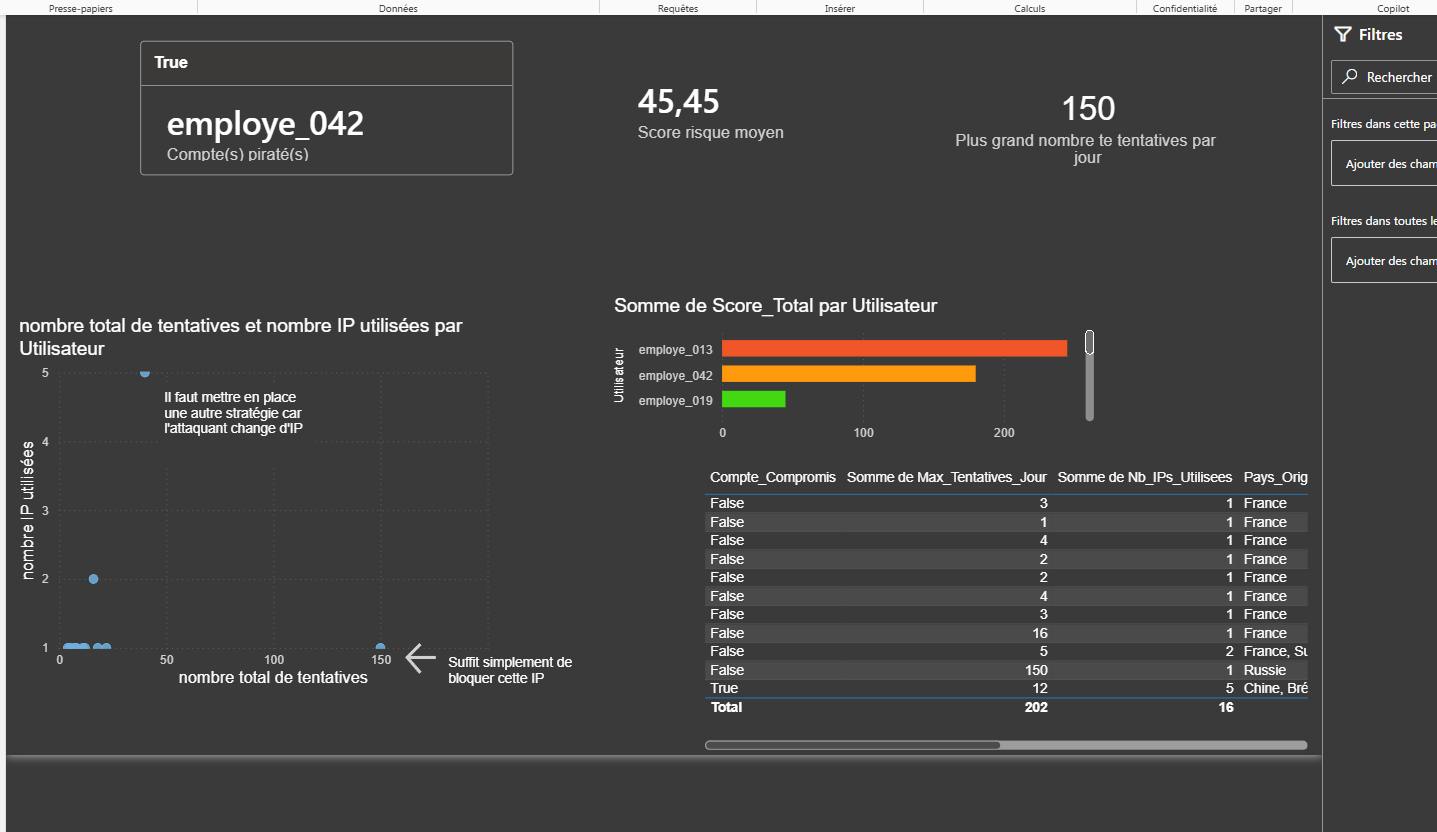

## Conclusion

Ce projet m'a vraiment permis de relier la technique au besoin métier. Le script Python fait tout le travail de fond pour détecter les anomalies, mais c'est ce tableau de bord qui donne l'alerte et permet à l'équipe de réagir. Mon objectif, c'était de montrer qu'on peut passer d'un simple fichier de logs bruts à un véritable outil d'aide à la décision.